In [1]:
import getpass
import os

if not os.environ.get("GROQ_API_KEY"):
  user = getpass.getuser()
  os.environ["GROQ_API_KEY"] = getpass.getpass(prompt="Enter Groq API key ")

In [2]:
from ai_module.LLMManager import LLMManager
# Initialize models
llm = LLMManager.get_model(temperature=0)

/home/brijeshdhaker/IdeaProjects/bd-crewai-module/.venv/lib/python3.13/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

class State(TypedDict):
  application: str
  experience_level: str
  skill_match : str
  response: str

#
workflow = StateGraph(State)

In [4]:
from langchain_core.prompts import (ChatPromptTemplate,
                                    AIMessagePromptTemplate,
                                    HumanMessagePromptTemplate,
                                    SystemMessagePromptTemplate
                                  )

def categorize_experience(state: State) -> State:
  print("\nCategorizing the experience level of candidate : ")
  prompt = ChatPromptTemplate.from_template(
      "Based on the following job application, categorize the candidate as 'Entry-level', 'Mid-level' or 'Senior-level'"
      "Application : {application}"
  )
  chain = prompt | llm
  experience_level = chain.invoke({"application": state["application"]}).content
  print(f"Experience Level : {experience_level}")
  return {"experience_level" : experience_level}

def assess_skillset(state: State) -> State:
  print("\nAssessing the skillset of candidate : ")
  prompt = ChatPromptTemplate.from_template(
      "Based on the job application for a Python Developer, assess the candidate's skillset"
      "Respond with either 'Match' or 'No Match'"
      "Application : {application}"
  )
  chain = prompt | llm
  skill_match = chain.invoke({"application": state["application"]}).content
  print(f"Skill Match : {skill_match}")
  return {"skill_match" : skill_match}

def schedule_hr_interview(state: State) -> State:
  print("\nScheduling the interview : ")
  return {"response" : "Scheduling the interview : Candidate has been shortlisted for an HR interview."}

def escalate_to_recruiter(state: State) -> State:
  print("Escalating to recruiter")
  return {"response" : "Escalating to recruiter : Candidate has senior-level experience but doesn't match job skills."}

def reject_application(state: State) -> State:
  print("Sending rejecting email")
  return {"response" : "Sending rejecting email : Candidate doesn't meet JD and has been rejected."}



In [5]:
workflow.add_node("categorize_experience", categorize_experience)
workflow.add_node("assess_skillset", assess_skillset)
workflow.add_node("schedule_hr_interview", schedule_hr_interview)
workflow.add_node("escalate_to_recruiter", escalate_to_recruiter)
workflow.add_node("reject_application", reject_application)

In [6]:
workflow.add_edge(START, "categorize_experience")
workflow.add_edge("categorize_experience", "assess_skillset")
workflow.add_edge("assess_skillset", END)
workflow.add_edge("escalate_to_recruiter", END)
workflow.add_edge("reject_application", END)
workflow.add_edge("schedule_hr_interview", END)

In [7]:
def route_app(state: State) -> str:
  if(state["skill_match"] == "Match"):
    return "schedule_hr_interview"
  elif(state["experience_level"] == "Senior-level"):
    return "escalate_to_recruiter"
  else:
    return "reject_application"

In [8]:

workflow.add_conditional_edges("assess_skillset", route_app,{
    "categorize_experience":"categorize_experience",
    "escalate_to_recruiter":"escalate_to_recruiter",
    "reject_application":"reject_application",
    "schedule_hr_interview":"schedule_hr_interview"
})

In [9]:
app = workflow.compile()

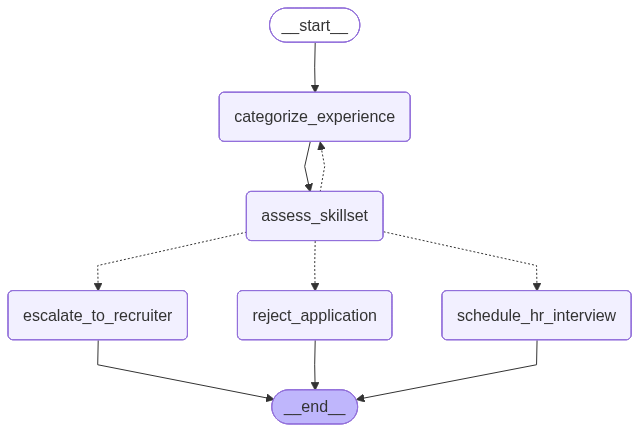

In [10]:
from IPython.display import Image, display
#
try:
  display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
  pass

In [11]:
def run_candidate_screening(application: str):
  results = app.invoke({"application" : application})
  return {
      "experience_level" : results["experience_level"],
      "skill_match" : results["skill_match"],
      "response" : results["response"]
  }

In [12]:
application_text = "I have 10 years of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


Categorizing the experience level of candidate : 
Experience Level : **Senior-level**

**Reasoning:**

A candidate with 10 years of experience is generally considered to be at a senior level. At this stage, employers typically expect the candidate to not only be technically proficient (expertise in JAVA) but also to possess skills in architecture, leading complex projects, mentoring junior staff, and solving ambiguous, high-level business problems, rather than just executing defined tasks.

Assessing the skillset of candidate : 
Skill Match : No Match
Sending rejecting email


Computed Results :
Application: I have 10 years of experience in software engineering with expertise in JAVA
Experience Level: **Senior-level**

**Reasoning:**

A candidate with 10 years of experience is generally considered to be at a senior level. At this stage, employers typically expect the candidate to not only be technically proficient (expertise in JAVA) but also to possess skills in architecture, leading

In [13]:
application_text = "I have 1 year of experience in software engineering with expertise in JAVA"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


Categorizing the experience level of candidate : 
Experience Level : **Category: Entry-level**

**Justification:**

One year of professional experience is generally considered foundational. Candidates at this stage are typically building core skills, gaining practical experience, and are expected to require some guidance while contributing to defined tasks.

*(Note: While the candidate has specific expertise (JAVA), the total duration of experience is the primary factor determining the seniority level.)*

Assessing the skillset of candidate : 
Skill Match : No Match
Sending rejecting email


Computed Results :
Application: I have 1 year of experience in software engineering with expertise in JAVA
Experience Level: **Category: Entry-level**

**Justification:**

One year of professional experience is generally considered foundational. Candidates at this stage are typically building core skills, gaining practical experience, and are expected to require some guidance while contributing to

In [18]:
application_text = "I have experience in software engineering with expertise in Python"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


Categorizing the experience level of candidate : 
Experience Level : Entry-level

Assessing the skillset of candidate : 
Skill Match : Match

Scheduling the interview : 


Computed Results :
Application: I have experience in software engineering with expertise in Python
Experience Level: Entry-level
Skill Match: Match
Response: Scheduling the interview : Candidate has been shortlisted for an HR interview.


In [20]:
application_text = "I have 5 years of experience in software engineering with expertise in C++"
results = run_candidate_screening(application_text)
print("\n\nComputed Results :")
print(f"Application: {application_text}")
print(f"Experience Level: {results['experience_level']}")
print(f"Skill Match: {results['skill_match']}")
print(f"Response: {results['response']}")


Categorizing the experience level of candidate : 
Experience Level : Mid-level

Assessing the skillset of candidate : 
Skill Match : No Match
Sending rejecting email


Computed Results :
Application: I have 5 years of experience in software engineering with expertise in C++
Experience Level: Mid-level
Skill Match: No Match
Response: Sending rejecting email : Candidate doesn't meet JD and has been rejected.
